# Paired multi-model analysis of scRNA-seq and scATAC-seq data

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.6'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.
    
    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.
    
    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
rna_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/1_ShareSeq_Skin/RNA'
atac_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/1_ShareSeq_Skin/ATAC'
metadata_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/1_ShareSeq_Skin/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"]
atac = data["atac"]
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [03:27<00:00, 69.31s/it] 


In [4]:
## load data
rna.X = rna.X.toarray().astype(float)
atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 34774 × 361596
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	34774 x 23296
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'nCount_ATAC', 'nFeature_ATAC', 'RNA.weight', 'ATAC.weight', 'nCount_DORC', 'nFeature_DORC', 'DORC_snn_res.0.8', 'RNA_snn_res.0.8', 'ATAC_snn_res.0.8', 'DORC.weight', 'Default_wsnn_res.0.8', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	34774 x 338300
      obs:	'barcodes', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'RNA_snn_res.0.5', 'seurat_clusters', 'celltype', 'nCount_ATAC', 'nFeature_ATAC', 'RNA.weight', 'ATAC.weight', 'nCount_DORC', 'nFeature_DORC', 'DORC_snn_res.0.8', 'RNA_snn_res.0.8', 'ATAC_snn_res.0.8', 'DORC.weight', 'Default_wsnn_res.0.8', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [5]:
rna.obs['celltype'].value_counts()

celltype
Basal                        7787
Infundibulum                 4139
TAC-1                        3370
Spinous                      3146
Mix                          2543
alowCD34+ bulge              1877
ahighCD34+ bulge             1556
Hair Shaft-cuticle.cortex    1166
Dermal Fibroblast            1121
ORS                          1029
TAC-2                        1008
Medulla                       981
Endothelial                   927
Dermal Papilla                766
Isthmus                       689
IRS                           672
K6+ Bulge Companion Layer     514
Dermal Sheath                 398
Granular                      291
Macrophage DC                 263
Melanocyte                    187
Sebaceous Gland               181
Schwann Cell                  163
Name: count, dtype: int64

         Falling back to preprocessing with `sc.pp.pca` and default params.


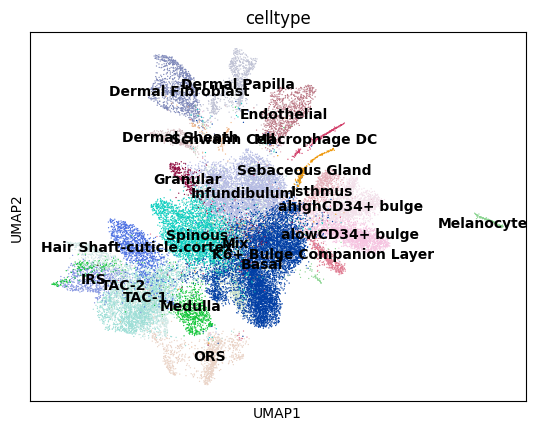

In [6]:
# process all RNA features
rna_adata = rna.copy()
sc.pp.normalize_total(rna_adata)
sc.pp.log1p(rna_adata)
sc.pp.highly_variable_genes(rna_adata)
# only retain highly variable genes
rna_adata = rna_adata[:, rna_adata.var.highly_variable].copy()
sc.pp.scale(rna_adata)

# plot UMAPs of rna cells based on all active rna markers
sc.pp.neighbors(rna_adata, n_neighbors=15)
sc.tl.umap(rna_adata)
sc.pl.umap(rna_adata, color=['celltype'], wspace=0.15, show=True, legend_loc='on data')

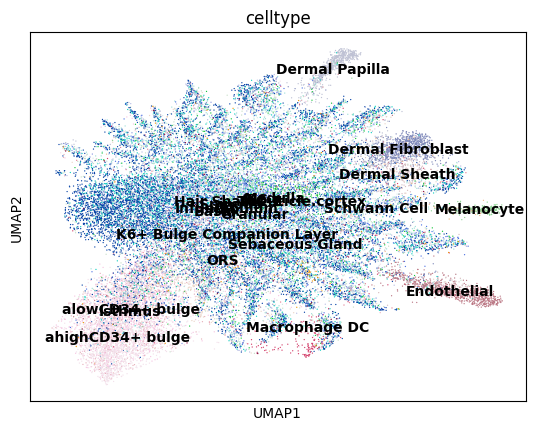

In [6]:
# process all RNA features
sc.pp.normalize_total(atac)
sc.pp.log1p(atac)
sc.pp.highly_variable_genes(atac, n_top_genes=10000)
# sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)
# only retain highly variable genes

atac = atac[:, atac.var.highly_variable].copy()
sc.pp.scale(atac)
sc.tl.pca(atac)

# plot UMAPs of rna cells based on all active rna markers
sc.pp.neighbors(atac, n_neighbors=15)
sc.tl.umap(atac)
sc.pl.umap(atac, color=['celltype'], wspace=0.15, show=True, legend_loc='on data')

## Perform single-cell multi-omics integration using Garfield

In [5]:
# set workdir
workdir = '/data2/zhouwg_data/project/Garfield_benchmark/results/RNA_ATAC/1_ShareSeq_Skin/'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome='hg38',
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=5., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=1.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_ATAC/1_ShareSeq_Skin/


In [ ]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---


In [ ]:
# Train model
model.train()

In [ ]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [ ]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data') 

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

gf.__version__

'0.3.6'

In [3]:
import pandas as pd
from scipy import io
from tqdm import tqdm

def check_file_exists(file_path):
    """Check if the file or directory exists and raise an error if not."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file or directory {file_path} does not exist.")

def read_rna_data(rna_dir):
    """Read RNA data including barcodes, features, and matrix from the specified directory."""
    rna_barcodes = pd.read_csv(f'{rna_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    rna_features = pd.read_csv(f'{rna_dir}/features.tsv', header=None, sep='\t', dtype=str)
    rna_matrix = io.mmread(f'{rna_dir}/matrix.mtx').T.tocsr()

    rna = sc.AnnData(X=rna_matrix)
    rna.var['gene_symbols'] = rna_features.iloc[:, 0].values
    rna.obs['barcodes'] = rna_barcodes.iloc[:, 0].values
    rna.var_names = rna.var['gene_symbols']  # Set feature names
    rna.obs_names = rna.obs['barcodes']  # Set barcode names
    return rna

def read_atac_data(atac_dir):
    """Read ATAC data from the specified CSV file and return it as an AnnData object."""
    atac_barcodes = pd.read_csv(f'{atac_dir}/barcodes.tsv', header=None, sep='\t', dtype=str)
    atac_features = pd.read_csv(f'{atac_dir}/features.tsv', header=None, sep='\t', dtype=str)
    atac_matrix = io.mmread(f'{atac_dir}/matrix.mtx').T.tocsr()

    atac = sc.AnnData(X=atac_matrix)
    atac.var['gene_symbols'] = atac_features.iloc[:, 0].values
    atac.obs['barcodes'] = atac_barcodes.iloc[:, 0].values
    atac.var_names = atac.var['gene_symbols']  # Set feature names
    atac.obs_names = atac.obs['barcodes']  # Set barcode names
    return atac

def read_metadata(metadata_file):
    """Read metadata from a CSV file and return it as a DataFrame."""
    return pd.read_csv(metadata_file, index_col=0)

def read_multiomics_data(rna_dir, atac_dir, metadata_file):
    """
    Reads and processes RNA and ADT data, adding metadata to both.
    
    Parameters:
        rna_dir (str): Path to the directory containing RNA matrix, barcodes, and features.
        atac_file (str): Path to the CSV file containing ATAC data.
        metadata_file (str): Path to the CSV file containing metadata.
    
    Returns:
        dict: A dictionary with keys "rna" and "adt" containing the corresponding AnnData objects.
    """
    # Ensure all paths exist
    check_file_exists(rna_dir)
    check_file_exists(atac_dir)
    check_file_exists(metadata_file)

    # Use progress feedback to track steps
    with tqdm(total=3, desc="Reading multiomics data") as pbar:
        # Read RNA data
        rna = read_rna_data(rna_dir)
        pbar.update(1)

        # Read ADT data
        atac = read_atac_data(atac_dir)
        pbar.update(1)

        # Read metadata
        metadata = read_metadata(metadata_file)
        metadata.index = rna.obs_names
        pbar.update(1)

    # Add metadata to RNA and ADT objects
    rna.obs = rna.obs.join(metadata, how="left")  # Ensure all metadata entries align
    atac.obs = atac.obs.join(metadata, how="left")

    return {"rna": rna, "atac": atac}

# Example usage with provided file paths
rna_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/5_human_brin_10x/RNA'
atac_dir = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/5_human_brin_10x/ATAC'
metadata_file = '/data2/zhouwg_data/project/Garfield_benchmark/datasets/MultiomicsBenchmark/Raw_data/RNA_ATAC/5_human_brin_10x/meta_data.csv'

# Read the data
data = read_multiomics_data(rna_dir, atac_dir, metadata_file)

# Access RNA and ADT data separately
rna = data["rna"]
atac = data["atac"]
rna.layers['counts'] = rna.X.copy()
atac.layers['counts'] = atac.X.copy()

Reading multiomics data: 100%|██████████| 3/3 [03:56<00:00, 78.88s/it] 


In [4]:
## load data
rna.X = rna.X.toarray().astype(float)
atac.X = atac.X.toarray().astype(float)
rna.var['feature_types'] = 'RNA'
atac.var['feature_types'] = 'ATAC'

# split each element for gene score calculation
split_data = atac.var_names.str.split('-', expand=True).to_frame(index=False)
split_data.index = atac.var_names
split_data.columns = ['chr', 'start', 'end']
atac.var[['chr', 'start', 'end']] = split_data

mdata = MuData({"rna": rna, "atac": atac})
mdata

MuData object with n_obs × n_vars = 2855 × 167463
  var:	'gene_symbols', 'feature_types'
  2 modalities
    rna:	2855 x 36601
      obs:	'barcodes', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.5', 'predicted.id', 'celltype', 'RNA.weight', 'ATAC.weight', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types'
      layers:	'counts'
    atac:	2855 x 130862
      obs:	'barcodes', 'nCount_RNA', 'nFeature_RNA', 'nCount_ATAC', 'nFeature_ATAC', 'TSS.enrichment', 'TSS.percentile', 'nucleosome_signal', 'nucleosome_percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'percent.mt', 'percent.ribo', 'ATAC_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.5', 'predicted.id', 'celltype', 'RNA.weight', 'ATAC.weight', 'wsnn_res.0.8'
      var:	'gene_symbols', 'feature_types', 'chr', 'start', 'end'
      layers:	'counts'

In [5]:
rna.obs['celltype'].value_counts()

celltype
Oligodendrocyte    1597
Astrocyte           506
OPC                 177
Microglia           160
IT                  155
VIP                 129
SST                 115
PVALB                16
Name: count, dtype: int64

         Falling back to preprocessing with `sc.pp.pca` and default params.


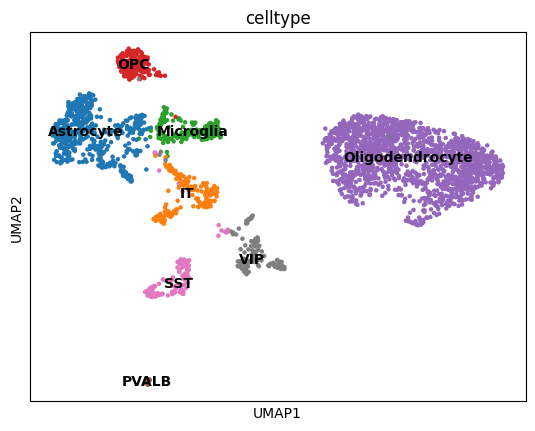

In [6]:
# process all RNA features
rna_adata = rna.copy()
sc.pp.normalize_total(rna_adata)
sc.pp.log1p(rna_adata)
sc.pp.highly_variable_genes(rna_adata)
# only retain highly variable genes
rna_adata = rna_adata[:, rna_adata.var.highly_variable].copy()
sc.pp.scale(rna_adata)

# plot UMAPs of rna cells based on all active rna markers
sc.pp.neighbors(rna_adata, n_neighbors=15)
sc.tl.umap(rna_adata)
sc.pl.umap(rna_adata, color=['celltype'], wspace=0.15, show=True, legend_loc='on data')

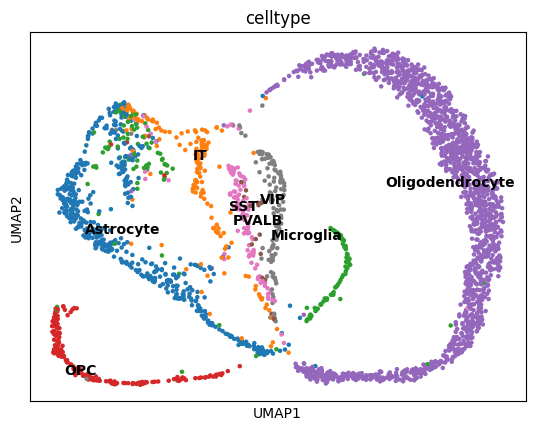

In [7]:
# process all RNA features
atac_adata = atac.copy()
sc.pp.normalize_total(atac_adata)
sc.pp.log1p(atac_adata)
sc.pp.highly_variable_genes(atac_adata, min_mean=0.05, max_mean=1.5, min_disp=.5)
# only retain highly variable genes

atac_adata = atac[:, atac_adata.var.highly_variable].copy()
sc.pp.scale(atac_adata)
sc.tl.pca(atac_adata)

# plot UMAPs of rna cells based on all active rna markers
sc.pp.neighbors(atac_adata, n_neighbors=15)
sc.tl.umap(atac_adata)
sc.pl.umap(atac_adata, color=['celltype'], wspace=0.15, show=True, legend_loc='on data')

## Perform single-cell multi-omics integration using Garfield

In [8]:
# set workdir
workdir = '/data2/zhouwg_data/project/Garfield_benchmark/results/RNA_ATAC/5_human_brin_10x/'
gf.settings.set_workdir(workdir)

### modify parameter
user_config = dict(
    ## Input options
    adata_list=mdata, 
    profile='multi-modal',   # if it is 'ATAC' or 'ADT', please adjust it.
    data_type='Paired',
    sub_data_type=['rna', 'atac'],
    sample_col=None,  # Specify columns for batch, only one batch, so set `None`
    weight=0.8,

    ## Preprocessing options
    genome='hg38',
    use_gene_weight=True,
    use_top_pcs=False,
    used_hvg=True,
    min_cells=3,
    min_features=0,
    keep_mt=False,
    target_sum=1e4,
    rna_n_top_features=3000,
    atac_n_top_features=10000, # if data belongs to 'ATAC', please specify it.
    n_components=50,
    n_neighbors=5,
    metric='euclidean',  
    svd_solver='arpack',
    # datasets
    used_pca_feat=True,
    adj_key='connectivities',
    
    # data split parameters
    edge_val_ratio=0.1,
    edge_test_ratio=0.,
    node_val_ratio=0.1,
    node_test_ratio=0.,

    ## Model options
    augment_type='svd',
    svd_q=5,
    use_FCencoder=False, 
    conv_type='GATv2Conv', # GAT or GATv2Conv or GCN
    gnn_layer=2,
    hidden_dims=[128, 128],
    bottle_neck_neurons=20,
    cluster_num=20,
    drop_feature_rate=0.2, 
    drop_edge_rate=0.2,
    num_heads=3,
    dropout=0.2,
    concat=True,
    used_edge_weight=True,
    used_DSBN=False,
    used_mmd=False,
    # data loader parameters
    num_neighbors=5,
    loaders_n_hops=2,
    edge_batch_size=4096,
    node_batch_size=128, # None
    # loss parameters
    include_edge_recon_loss=True,
    include_gene_expr_recon_loss=True,
    lambda_latent_contrastive_instanceloss=1.0,
    lambda_latent_contrastive_clusterloss=0.5,
    lambda_gene_expr_recon=1., # To make the model more focused on learning expression features, increase this parameter.
    lambda_edge_recon=5., # To make the model more focused on learning Adjacency graph features, increase this parameter.
    lambda_latent_adj_recon_loss=1.0,
    lambda_omics_recon_mmd_loss=3., # If the integration is not strong enough, increase it.
    # train parameters
    n_epochs_no_edge_recon=0,
    learning_rate=0.001,
    weight_decay=1e-05,
    gradient_clipping=5,
    # other parameters
    latent_key='garfield_latent',
    reload_best_model=True,
    use_early_stopping=True,
    early_stopping_kwargs=None,
    monitor=True,
    device_id=1,
    seed=2024,
    verbose=True
)
dict_config = gf.settings.set_gf_params(user_config)

Saving results in: /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_ATAC/1_ShareSeq_Skin/


In [9]:
from Garfield.model import Garfield

# Initialize model
model = Garfield(dict_config)

--- DATA LOADING AND PREPROCESSING ---
Converting peak to gene activity matrix, this might take a while...
Gene scores are being calculated for the first time
`use_precomputed` has been ignored
Processing: 0.0%
Processing: 20.0%
Processing: 40.0%
Processing: 60.0%
Processing: 80.0%
adata object cached at: /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_ATAC/1_ShareSeq_Skin/adata_ATAC_cache.h5ad
There are 19354 common genes in RNA and ATAC datasets
To start performing cell matching for adjacency matrix of the graph, please wait...
Init_matching done!
Finding initial pivots costs 47.97 seconds.
Refined_matching done!
Filter_bad_matches on pivots matching...
Begin filtering...
1998/2855 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
Done!
Filter_bad_matches on propagated matching...
Begin filtering...
1714/1714 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
COSINE SIM GRAP

In [10]:
# Train model
model.train()


--- INITIALIZING TRAINER ---
Number of training nodes: 2569
Number of validation nodes: 286
Number of training edges: 19045
Number of validation edges: 2116
Edge batch size: 4096
Node batch size: 128

--- MODEL TRAINING ---
Epoch 1/100 |--------------------| 1.0% val_auroc_score: 0.8800; val_auprc_score: 0.8665; val_best_acc_score: 0.8008; val_best_f1_score: 0.8151; train_kl_reg_loss: 20992251898.9328; train_edge_recon_loss: 5285.1409; train_gene_expr_recon_loss: 5651004977405.5996; train_lambda_latent_adj_recon_loss: 1258.1103; train_lambda_latent_contrastive_instanceloss: 7.1364; train_lambda_latent_contrastive_clusterloss: 3.7533; train_global_loss: 5671997119715.0996; train_optim_loss: 5671997119715.0996; val_kl_reg_loss: 423.8876; val_edge_recon_loss: 3087.9968; val_gene_expr_recon_loss: 279721.9688; val_lambda_latent_adj_recon_loss: 1443.2119; val_lambda_latent_contrastive_instanceloss: 6.9449; val_lambda_latent_contrastive_clusterloss: 3.6678; val_global_loss: 284687.6562; val_

In [11]:
# Compute latent neighbor graph
latent_key = 'garfield_latent'
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)
# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

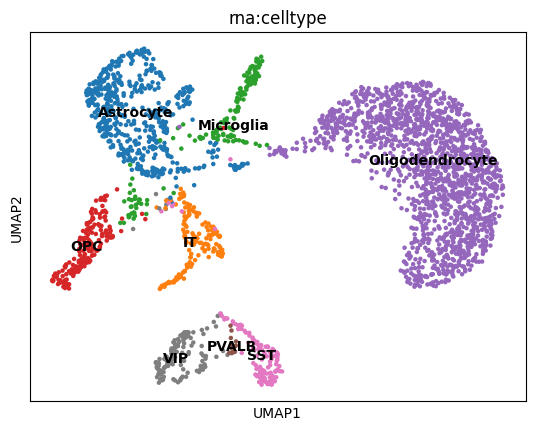

In [12]:
sc.pl.umap(model.adata, color=['rna:celltype'], wspace=0.15, show=True, legend_loc='on data') 

In [15]:
# Save trained model
model_folder_path = f"{workdir}/model"
os.makedirs(model_folder_path, exist_ok=True)

del model.adata.obsm['feat']
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata_ref.h5ad")

Pickle failed with error: Can't pickle local object 'WeakSet.__init__.<locals>._remove', switching to dill...
Model saved successfully using dill at /data2/zhouwg_data/project/Garfield_benchmark/results/RNA_ATAC/1_ShareSeq_Skin//model/attr.pkl
